# Clasificacion de COVID-19 a partir del sonido de la tos

**Curso:** Machine Learning - Maestria en DS/AI, UTEC
**Profesor:** Cristian Lopez Del Alamo
**Integrantes:** Roger Reategui Soto, Erick Rosas Pisfil, Yemar Puma Huaman
**Repositorio:** https://github.com/erosas-utec/ml-project-classification

## 1. Introduccion

El objetivo de este proyecto es clasificar pacientes como COVID positivo o negativo empleando unicamente el sonido de su tos. El conjunto de datos proviene de las colecciones COSWARA y Virufy e incluye 1207 toses de personas con prueba negativa y 150 de personas positivas.

El plan de trabajo es el siguiente:

1. Cargar y limpiar el conjunto de audios.
2. Convertir cada audio en un vector de caracteristicas mediante MFCC.
3. Entrenar y comparar Regresion Logistica, SVM, Arbol de Decision y KNN (los cuatro modelos solicitados), ademas de Random Forest como metodo adicional (visto en el capitulo de arboles del curso).
4. Realizar el entrenamiento con validacion cruzada K-fold (K=5), probando distintos hiperparametros por modelo y reportando Accuracy, Precision, Recall y F1 en cada prueba.
5. Estudiar estrategias para mejorar la deteccion de la clase positiva, que es la minoritaria.
6. Evaluar el mejor modelo sobre un conjunto de test (20%) separado al inicio, generando la matriz de confusion con los porcentajes por clase.

Se fija una semilla en todo el proyecto para que los resultados sean reproducibles.

In [1]:
# Librerias utilizadas en el proyecto
import os
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa

from sklearn.model_selection import (train_test_split, StratifiedGroupKFold,
                                      cross_validate, cross_val_predict)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, precision_score,
                             recall_score, f1_score, confusion_matrix,
                             classification_report, make_scorer)

warnings.filterwarnings('ignore')

# Semilla global para reproducibilidad (requisito del curso)
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Constantes del proyecto
SR = 22050        # frecuencia de muestreo unica; los audios llegan en 44.1 kHz y 48 kHz
N_MFCC = 20       # numero de coeficientes MFCC
DATA_DIR = Path('insumos_originales/cough_sounds/cleaned_data')  # insumos dados, dentro del repo
FEATURES_CSV = Path('data/features.csv')

sns.set_theme(style='whitegrid')
PALETA = sns.color_palette('colorblind')

## 2. Carga y exploracion de los datos

Los audios se encuentran en tres carpetas: `Negative`, `Positive` y `Unknown`. El nombre de cada archivo sigue el patron `id_Etiqueta_genero_edad`, por ejemplo `0_Negative_male_26.wav`.

Durante la revision del conjunto se identificaron varios aspectos que se resuelven antes del entrenamiento:

- La etiqueta se toma de la carpeta y no del nombre del archivo, ya que nueve archivos presentan el error tipografico `Postive`.
- La carpeta `Positive` mezcla formatos: 102 archivos `.wav` y 48 `.mp3`. Se conservan los `.mp3`, pues librosa los lee sin inconveniente y los positivos constituyen la clase escasa.
- La carpeta `Unknown` (73 audios) no tiene etiqueta, por lo que no aporta al entrenamiento ni a la medicion de metricas y se descarta.
- Cinco pacientes positivos aportan varias grabaciones (por ejemplo, el paciente 1521 tiene 22 audios). Se verifico mediante sumas de verificacion que son grabaciones distintas y no copias, de modo que se conservan; mas adelante se garantiza que todas las grabaciones de un mismo paciente permanezcan en el mismo conjunto.
- La edad y el genero se mantienen unicamente como datos descriptivos (ademas existen edades mal registradas), ya que el proyecto pide clasificar solo con el sonido.

In [2]:
# Se recorren las carpetas Negative y Positive y se arma una tabla con la informacion de cada audio
registros = []
for clase in ['Negative', 'Positive']:
    for archivo in sorted((DATA_DIR / clase).glob('*')):
        if archivo.suffix.lower() not in ['.wav', '.mp3']:
            continue
        nombre = archivo.stem
        partes = nombre.split('_')
        registros.append({
            'archivo': archivo.name,
            'ruta': str(archivo),
            'clase': clase,                   # la carpeta es la etiqueta confiable
            'id_paciente': partes[0],
            'genero': partes[2],
            'edad': partes[3].split(' ')[0],  # se elimina el sufijo ' (n)' de grabaciones repetidas
            'formato': archivo.suffix.lower(),
        })

df = pd.DataFrame(registros)
df['y'] = (df['clase'] == 'Positive').astype(int)   # 1 = COVID positivo, 0 = negativo

print('Total de audios:', len(df))
print()
print(df['clase'].value_counts())
print()
print(df.groupby('clase')['formato'].value_counts())
df.head()

Total de audios: 1357

clase
Negative    1207
Positive     150
Name: count, dtype: int64

clase     formato
Negative  .wav       1207
Positive  .wav        102
          .mp3         48
Name: count, dtype: int64


,archivo,ruta,clase,id_paciente,genero,edad,formato,y
0,0_Negative_male_26.wav,insumos_originales\cough_sounds\cleaned_data\N...,Negative,0,male,26,.wav,0
1,1001_Negative_male_30.wav,insumos_originales\cough_sounds\cleaned_data\N...,Negative,1001,male,30,.wav,0
2,1002_Negative_male_27.wav,insumos_originales\cough_sounds\cleaned_data\N...,Negative,1002,male,27,.wav,0
3,1003_Negative_male_30.wav,insumos_originales\cough_sounds\cleaned_data\N...,Negative,1003,male,30,.wav,0
4,1004_Negative_male_29.wav,insumos_originales\cough_sounds\cleaned_data\N...,Negative,1004,male,29,.wav,0


Pacientes unicos por clase:
clase
Negative    1207
Positive     117
Name: id_paciente, dtype: int64

Pacientes con mas de una grabacion:
id_paciente
1521    22
1524     7
1523     5
1503     2
1522     2
Name: count, dtype: int64


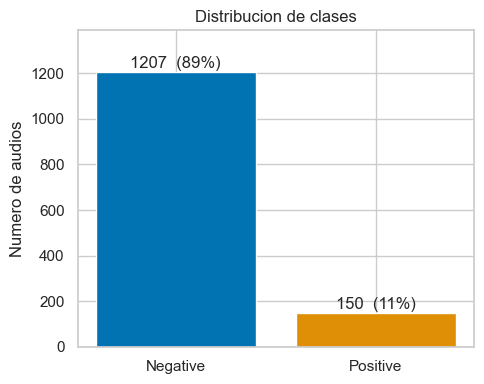

In [3]:
# Se revisa el desbalance de clases y los pacientes con mas de una grabacion
print('Pacientes unicos por clase:')
print(df.groupby('clase')['id_paciente'].nunique())

repetidos = df['id_paciente'].value_counts()
print()
print('Pacientes con mas de una grabacion:')
print(repetidos[repetidos > 1])

fig, ax = plt.subplots(figsize=(5, 4))
conteo = df['clase'].value_counts()
ax.bar(conteo.index, conteo.values, color=[PALETA[0], PALETA[1]])
for i, v in enumerate(conteo.values):
    ax.text(i, v + 15, f'{v}  ({v / len(df):.0%})', ha='center')
ax.set_ylim(0, conteo.max() * 1.15)
ax.set_ylabel('Numero de audios')
ax.set_title('Distribucion de clases')
plt.tight_layout()
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/distribucion_clases.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Extraccion de caracteristicas con MFCC

Un audio en crudo es una senal larga y de duracion variable (entre 2.5 s y 26 s), por lo que no puede usarse directamente como entrada de los modelos. El enunciado permite emplear librerias para obtener el mejor vector de caracteristicas; se utilizan los MFCC (Mel-Frequency Cepstral Coefficients) de librosa, que resumen el timbre del sonido en pocas dimensiones.

Para cada audio se calcula la matriz de 20 MFCC por ventana de tiempo y se resume con la media y la desviacion estandar de cada coeficiente, obteniendo un vector fijo de 40 caracteristicas por audio, con independencia de su duracion. Ademas, `librosa.load` remuestrea todo a 22050 Hz, lo que unifica los audios que llegan en 44.1 kHz y 48 kHz.

El resultado se guarda en `data/features.csv`; si el archivo ya existe se carga directamente, dado que el calculo es determinista.

In [4]:
def extraer_features(ruta):
    """Carga un audio y devuelve su vector de 40 caracteristicas (media y std de 20 MFCC) y su duracion."""
    senal, sr = librosa.load(ruta, sr=SR)
    mfcc = librosa.feature.mfcc(y=senal, sr=sr, n_mfcc=N_MFCC)
    vector = np.concatenate([mfcc.mean(axis=1), mfcc.std(axis=1)])
    return vector, len(senal) / sr


columnas_feat = [f'mfcc_mean_{i}' for i in range(N_MFCC)] + [f'mfcc_std_{i}' for i in range(N_MFCC)]

if FEATURES_CSV.exists():
    df_feat = pd.read_csv(FEATURES_CSV, dtype={'id_paciente': str})
    print('Caracteristicas cargadas desde', FEATURES_CSV)
else:
    filas, fallidos = [], []
    for i, audio in df.iterrows():
        try:
            vector, duracion = extraer_features(audio['ruta'])
            filas.append(list(vector) + [duracion])
        except Exception as error:
            fallidos.append((audio['archivo'], str(error)))
            filas.append([np.nan] * N_MFCC * 2 + [np.nan])
        if (i + 1) % 200 == 0:
            print(f'  procesados {i + 1} de {len(df)} audios...')

    df_feat = pd.concat([df.reset_index(drop=True),
                         pd.DataFrame(filas, columns=columnas_feat + ['duracion_s'])], axis=1)
    df_feat = df_feat.dropna(subset=columnas_feat).reset_index(drop=True)
    print('Audios que no se pudieron leer:', len(fallidos), fallidos[:5])
    FEATURES_CSV.parent.mkdir(exist_ok=True)
    df_feat.to_csv(FEATURES_CSV, index=False)
    print('Caracteristicas guardadas en', FEATURES_CSV)

print('Tabla final de caracteristicas:', df_feat.shape)
df_feat.head()

Caracteristicas cargadas desde data\features.csv
Tabla final de caracteristicas: (1357, 49)


,archivo,ruta,clase,id_paciente,genero,edad,formato,y,mfcc_mean_0,mfcc_mean_1,...,mfcc_std_11,mfcc_std_12,mfcc_std_13,mfcc_std_14,mfcc_std_15,mfcc_std_16,mfcc_std_17,mfcc_std_18,mfcc_std_19,duracion_s
0,0_Negative_male_26.wav,insumos_originales\cough_sounds\cleaned_data\N...,Negative,0,male,26,.wav,0,-340.55215,66.880646,...,12.314476,9.836579,8.982395,10.383850,10.142530,7.343030,8.333507,10.032979,7.666974,5.973333
1,1001_Negative_male_30.wav,insumos_originales\cough_sounds\cleaned_data\N...,Negative,1001,male,30,.wav,0,-283.26370,85.185930,...,16.415142,13.796118,14.757615,9.710491,8.326899,11.713878,10.451915,8.480636,9.081613,6.058685
2,1002_Negative_male_27.wav,insumos_originales\cough_sounds\cleaned_data\N...,Negative,1002,male,27,.wav,0,-475.69830,57.115220,...,8.263861,8.920180,11.147167,9.908153,4.594748,6.948964,7.243165,6.947069,5.681151,4.608027
3,1003_Negative_male_30.wav,insumos_originales\cough_sounds\cleaned_data\N...,Negative,1003,male,30,.wav,0,-347.25577,27.227205,...,8.474210,11.683063,11.065142,10.090658,11.602316,7.598847,9.883102,7.461547,7.870695,10.154694
4,1004_Negative_male_29.wav,insumos_originales\cough_sounds\cleaned_data\N...,Negative,1004,male,29,.wav,0,-398.64404,58.635323,...,7.992653,8.589902,9.154720,8.590487,7.404130,10.150194,9.226245,8.549302,6.414618,3.242676


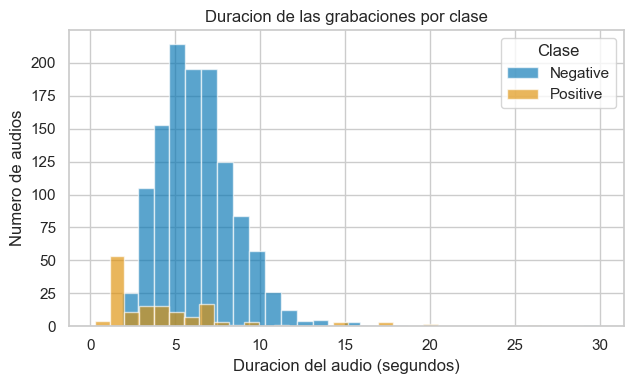

,count,mean,std,min,25%,50%,75%,max
clase,,,,,,,,
Negative,1207.0,6.34,2.30,1.86,4.78,6.14,7.59,29.95
Positive,150.0,4.49,4.22,0.26,1.60,3.29,6.06,26.62


In [5]:
# Distribucion de las duraciones por clase (solo descriptivo; los MFCC ya normalizan la duracion)
fig, ax = plt.subplots(figsize=(6.5, 4))
for clase, color in [('Negative', PALETA[0]), ('Positive', PALETA[1])]:
    ax.hist(df_feat.loc[df_feat['clase'] == clase, 'duracion_s'],
            bins=30, alpha=0.65, label=clase, color=color)
ax.set_xlabel('Duracion del audio (segundos)')
ax.set_ylabel('Numero de audios')
ax.set_title('Duracion de las grabaciones por clase')
ax.legend(title='Clase')
plt.tight_layout()
plt.savefig('figures/duraciones.png', dpi=150, bbox_inches='tight')
plt.show()

df_feat.groupby('clase')['duracion_s'].describe().round(2)

## 4. Modelos a comparar

A continuacion se describe brevemente cada modelo, segun lo visto en el curso:

- **Regresion Logistica** (Cap. 2.1): aplica la funcion sigmoide sobre una combinacion lineal de las caracteristicas y devuelve la probabilidad de ser positivo. Se entrena minimizando la log-loss mediante descenso de gradiente. Su hiperparametro principal es `C`, el inverso de la regularizacion L2.
- **SVM** (Cap. 2.2): busca el hiperplano que separa las clases maximizando el margen. El margen suave (`C`) tolera algunos errores, y los kernels (lineal, RBF) permiten separar datos que no son linealmente separables llevandolos a una dimension mayor.
- **Arbol de Decision** (Cap. 2.3): divide los datos con preguntas sobre las caracteristicas, eligiendo en cada nodo la particion que mas reduce el desorden, medido con entropia (ganancia de informacion) o con impureza de Gini. Su principal riesgo es el sobreajuste, que se controla limitando la profundidad (`max_depth`).
- **KNN** (Cap. 2.4): clasifica cada audio por votacion de sus K vecinos mas cercanos. No tiene fase de entrenamiento explicita (lazy learning). Debe considerarse la maldicion de la dimensionalidad; con 40 caracteristicas aun trabaja adecuadamente.
- **Random Forest** (Cap. 2.3): es un ensamble por bagging de arboles de decision con aleatoriedad adicional en las caracteristicas, lo que reduce el sobreajuste del arbol individual. Se incluye como el metodo adicional que permite el enunciado.

**Sobre las metricas** (Cap. 2.5): con un conjunto 89/11, el accuracy por si solo resulta enganoso, pues un modelo que prediga siempre la clase negativa alcanzaria alrededor de 89% sin detectar ningun caso de COVID. Por ello se reporta ademas la balanced accuracy y se mide precision, recall y F1 sobre la clase positiva, que es la de interes. El F1 de la clase positiva es la metrica con la que se elige la mejor configuracion.

## 5. Separacion train/test y escalado

Se separa el 20% para test de forma estratificada (mantiene la proporcion 89/11) y a nivel de paciente: primero se reparten los pacientes y luego se asignan sus grabaciones. De este modo, si un paciente tiene varias grabaciones, todas quedan en el mismo conjunto; en caso contrario el modelo podria reconocer al paciente en el test y las metricas resultarian infladas (fuga de datos).

Este conjunto de test es el que se emplea al final como el "test data" que pide el proyecto para la matriz de confusion.

A continuacion se estandarizan las caracteristicas (el Cap. 2.1 recomienda normalizar): el `StandardScaler` se ajusta unicamente con el train y esa transformacion se aplica al test, para no filtrar informacion del test hacia el entrenamiento.

In [6]:
# Se reparten los pacientes (no los audios) entre train y test, estratificando por clase
pacientes = df_feat[['id_paciente', 'y']].drop_duplicates('id_paciente')
pac_train, pac_test = train_test_split(pacientes['id_paciente'], test_size=0.20,
                                       stratify=pacientes['y'], random_state=SEED)

train = df_feat[df_feat['id_paciente'].isin(pac_train)]
test = df_feat[df_feat['id_paciente'].isin(pac_test)]

X_train = train[columnas_feat].values
y_train = train['y'].values
grupos_train = train['id_paciente'].values   # para que el K-fold tambien respete a los pacientes
X_test = test[columnas_feat].values
y_test = test['y'].values

# Estandarizacion: el scaler se ajusta solo con train
scaler = StandardScaler().fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

print(f'Train: {len(train)} audios de {len(pac_train)} pacientes '
      f'({train["y"].mean():.1%} positivos)')
print(f'Test:  {len(test)} audios de {len(pac_test)} pacientes '
      f'({test["y"].mean():.1%} positivos)')

Train: 1067 audios de 1059 pacientes (9.6% positivos)
Test:  290 audios de 265 pacientes (16.6% positivos)


## 6. Experimentos con validacion cruzada K-fold

La seleccion de hiperparametros se realiza unicamente sobre el train (80%) mediante validacion cruzada de 5 folds. Se utiliza `StratifiedGroupKFold`: estratificado para que cada fold mantenga la proporcion 89/11, y agrupado para que las grabaciones de un mismo paciente no queden repartidas entre folds (por la misma razon del split de test).

Para cada combinacion de hiperparametros se entrena cinco veces y se reporta el promedio de Accuracy, Balanced Accuracy, Precision, Recall y F1 (estas tres ultimas sobre la clase positiva), que es la tabla solicitada por el proyecto.

In [7]:
kfold = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)

# precision/recall/f1 con zero_division=0: si un modelo no predice ningun positivo,
# la metrica vale 0 en lugar de generar error
metricas = {
    'accuracy': 'accuracy',
    'balanced_acc': 'balanced_accuracy',
    'precision': make_scorer(precision_score, zero_division=0),
    'recall': make_scorer(recall_score, zero_division=0),
    'f1': make_scorer(f1_score, zero_division=0),
}


def evaluar(modelo, X, y=None, grupos=None):
    """Ejecuta la validacion cruzada de 5 folds y devuelve el promedio de cada metrica."""
    y = y_train if y is None else y
    grupos = grupos_train if grupos is None else grupos
    cv = cross_validate(modelo, X, y, groups=grupos, cv=kfold, scoring=metricas)
    return {m: round(cv['test_' + m].mean(), 3) for m in metricas}

### 6.1 Regresion Logistica

Se prueban tres niveles de regularizacion con `C` (inverso de la fuerza de la regularizacion L2).

In [8]:
resultados = []
for C in [0.1, 1, 10]:
    modelo = LogisticRegression(C=C, max_iter=5000, random_state=SEED)
    resultados.append({'C': C, **evaluar(modelo, X_train)})

tabla_lr = pd.DataFrame(resultados)
tabla_lr

,C,accuracy,balanced_acc,precision,recall,f1
0,0.1,0.903,0.521,0.433,0.049,0.087
1,1.0,0.900,0.537,0.399,0.089,0.142
2,10.0,0.897,0.535,0.366,0.089,0.139


### 6.2 SVM

Se prueban el kernel lineal y el RBF, cada uno con tres valores de `C` (margen suave). El parametro `gamma` se deja en `'scale'`, el valor automatico de sklearn.

In [9]:
resultados = []
for kernel in ['linear', 'rbf']:
    for C in [0.1, 1, 10]:
        modelo = SVC(kernel=kernel, C=C, gamma='scale', random_state=SEED)
        resultados.append({'kernel': kernel, 'C': C, **evaluar(modelo, X_train)})

tabla_svm = pd.DataFrame(resultados)
tabla_svm

,kernel,C,accuracy,balanced_acc,precision,recall,f1
0,linear,0.1,0.904,0.500,0.000,0.000,0.000
1,linear,1.0,0.904,0.500,0.000,0.000,0.000
2,linear,10.0,0.904,0.500,0.000,0.000,0.000
3,rbf,0.1,0.904,0.500,0.000,0.000,0.000
4,rbf,1.0,0.910,0.530,0.800,0.060,0.110
5,rbf,10.0,0.905,0.615,0.522,0.255,0.339


### 6.3 Arbol de Decision

Se comparan los dos criterios de division vistos en el curso (Gini y entropia) y varias profundidades maximas para controlar el sobreajuste (`None` = sin limite).

In [10]:
resultados = []
for criterio in ['gini', 'entropy']:
    for profundidad in [3, 5, 10, None]:
        modelo = DecisionTreeClassifier(criterion=criterio, max_depth=profundidad, random_state=SEED)
        resultados.append({'criterion': criterio, 'max_depth': str(profundidad),
                           **evaluar(modelo, X_train)})

tabla_dt = pd.DataFrame(resultados)
tabla_dt

,criterion,max_depth,accuracy,balanced_acc,precision,recall,f1
0,gini,3,0.900,0.511,0.167,0.030,0.051
1,gini,5,0.895,0.548,0.344,0.118,0.172
2,gini,10,0.868,0.555,0.218,0.169,0.190
3,gini,None,0.858,0.581,0.229,0.238,0.233
4,entropy,3,0.899,0.527,0.333,0.068,0.100
5,entropy,5,0.879,0.552,0.283,0.147,0.192
6,entropy,10,0.850,0.567,0.216,0.216,0.214
7,entropy,None,0.839,0.569,0.203,0.236,0.218


### 6.4 KNN

Se prueban varios valores de K y las dos formas de votar: `uniform` (todos los vecinos pesan igual) y `distance` (los vecinos mas cercanos pesan mas).

In [11]:
resultados = []
for k in [3, 5, 7, 11]:
    for pesos in ['uniform', 'distance']:
        modelo = KNeighborsClassifier(n_neighbors=k, weights=pesos)
        resultados.append({'n_neighbors': k, 'weights': pesos, **evaluar(modelo, X_train)})

tabla_knn = pd.DataFrame(resultados)
tabla_knn

,n_neighbors,weights,accuracy,balanced_acc,precision,recall,f1
0,3,uniform,0.906,0.588,0.531,0.195,0.283
1,3,distance,0.906,0.588,0.531,0.195,0.283
2,5,uniform,0.913,0.570,0.730,0.147,0.242
3,5,distance,0.914,0.575,0.750,0.157,0.256
4,7,uniform,0.912,0.548,0.833,0.098,0.174
5,7,distance,0.915,0.558,0.933,0.117,0.206
6,11,uniform,0.907,0.515,0.600,0.029,0.055
7,11,distance,0.908,0.520,0.800,0.039,0.074


### 6.5 Random Forest (metodo adicional)

Ensamble por bagging de arboles (Cap. 2.3). Se prueba el numero de arboles y la profundidad maxima.

In [12]:
resultados = []
for n_arboles in [100, 200]:
    for profundidad in [5, 10, None]:
        modelo = RandomForestClassifier(n_estimators=n_arboles, max_depth=profundidad,
                                        random_state=SEED)
        resultados.append({'n_estimators': n_arboles, 'max_depth': str(profundidad),
                           **evaluar(modelo, X_train)})

tabla_rf = pd.DataFrame(resultados)
tabla_rf

,n_estimators,max_depth,accuracy,balanced_acc,precision,recall,f1
0,100,5,0.906,0.510,0.4,0.02,0.038
1,100,10,0.906,0.514,0.4,0.03,0.055
2,100,None,0.907,0.519,0.6,0.04,0.074
3,200,5,0.906,0.510,0.4,0.02,0.038
4,200,10,0.907,0.515,0.4,0.03,0.055
5,200,None,0.908,0.520,0.6,0.04,0.074


## 7. Comparacion entre modelos (linea base)

Se toma la mejor configuracion de cada modelo (segun el F1 de la clase positiva en la validacion cruzada) y se comparan en una sola tabla y una grafica. Estos resultados constituyen la linea base, sobre la cual las Secciones 8 y 9 evaluan estrategias de mejora.

In [13]:
tablas = {
    'Regresion Logistica': tabla_lr,
    'SVM': tabla_svm,
    'Arbol de Decision': tabla_dt,
    'KNN': tabla_knn,
    'Random Forest': tabla_rf,
}
cols_metricas = ['accuracy', 'balanced_acc', 'precision', 'recall', 'f1']

mejores, fila_ganadora = [], {}
for nombre, tabla in tablas.items():
    fila = tabla.sort_values('f1', ascending=False).iloc[0]
    fila_ganadora[nombre] = fila
    config = ', '.join(f'{col}={fila[col]}' for col in tabla.columns if col not in cols_metricas)
    mejores.append({'modelo': nombre, 'mejor configuracion': config,
                    **fila[cols_metricas].to_dict()})

tabla_mejores = pd.DataFrame(mejores).sort_values('f1', ascending=False).reset_index(drop=True)
nombre_mejor = tabla_mejores.iloc[0]['modelo']
print('Mejor modelo de la linea base (por F1 de la clase positiva):', nombre_mejor)
tabla_mejores

Mejor modelo de la linea base (por F1 de la clase positiva): SVM


,modelo,mejor configuracion,accuracy,balanced_acc,precision,recall,f1
0,SVM,"kernel=rbf, C=10.0",0.905,0.615,0.522,0.255,0.339
1,KNN,"n_neighbors=3, weights=uniform",0.906,0.588,0.531,0.195,0.283
2,Arbol de Decision,"criterion=gini, max_depth=None",0.858,0.581,0.229,0.238,0.233
3,Regresion Logistica,C=1.0,0.900,0.537,0.399,0.089,0.142
4,Random Forest,"n_estimators=200, max_depth=None",0.908,0.520,0.600,0.040,0.074


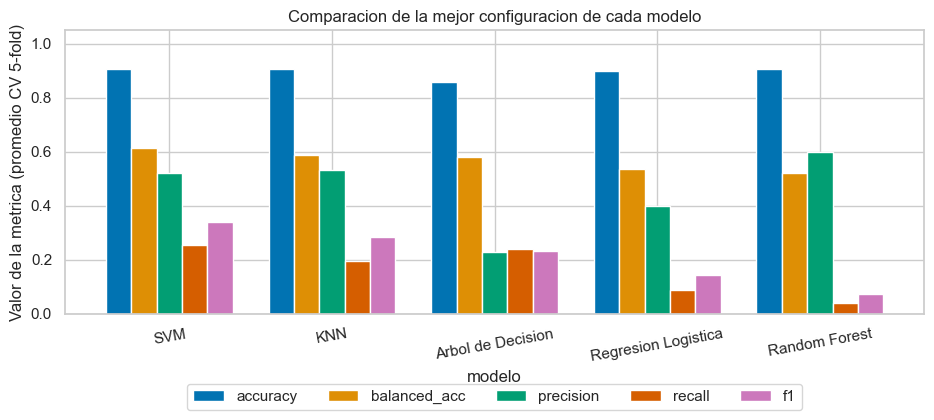

In [14]:
fig, ax = plt.subplots(figsize=(9.5, 4.5))
tabla_plot = tabla_mejores.set_index('modelo')[cols_metricas]
tabla_plot.plot.bar(ax=ax, color=PALETA[:5], width=0.78, rot=10)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Valor de la metrica (promedio CV 5-fold)')
ax.set_title('Comparacion de la mejor configuracion de cada modelo')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.22), ncols=5)
plt.tight_layout()
plt.savefig('figures/comparacion_modelos.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
# Se guardan las tablas de resultados en CSV para elaborar el informe
os.makedirs('results', exist_ok=True)
slugs = {'Regresion Logistica': 'logistic_regression', 'SVM': 'svm',
         'Arbol de Decision': 'decision_tree', 'KNN': 'knn', 'Random Forest': 'random_forest'}
for nombre, tabla in tablas.items():
    tabla.to_csv(f'results/{slugs[nombre]}.csv', index=False)
tabla_mejores.to_csv('results/comparacion_modelos.csv', index=False)
print('Tablas guardadas en la carpeta results/')

Tablas guardadas en la carpeta results/


In [16]:
def construir_modelo(nombre, fila, class_weight=None):
    """Reconstruye un modelo con los hiperparametros ganadores de su tabla.
    class_weight permite activar el balanceo de clases (Seccion 8)."""
    if nombre == 'Regresion Logistica':
        return LogisticRegression(C=fila['C'], max_iter=5000, class_weight=class_weight,
                                  random_state=SEED)
    if nombre == 'SVM':
        return SVC(kernel=fila['kernel'], C=fila['C'], gamma='scale', probability=True,
                   class_weight=class_weight, random_state=SEED)
    if nombre == 'Arbol de Decision':
        prof = None if fila['max_depth'] == 'None' else int(fila['max_depth'])
        return DecisionTreeClassifier(criterion=fila['criterion'], max_depth=prof,
                                      class_weight=class_weight, random_state=SEED)
    if nombre == 'KNN':
        return KNeighborsClassifier(n_neighbors=int(fila['n_neighbors']), weights=fila['weights'])
    prof = None if fila['max_depth'] == 'None' else int(fila['max_depth'])
    return RandomForestClassifier(n_estimators=int(fila['n_estimators']), max_depth=prof,
                                  class_weight=class_weight, random_state=SEED)

## 8. Reduccion de dimensionalidad: PCA y LDA

El Cap. 3 presenta dos tecnicas de reduccion de dimensionalidad. PCA (no supervisada) proyecta los datos a las direcciones de mayor varianza; LDA (supervisada) busca la direccion que mejor separa las clases. Se evalua si el mejor modelo de la linea base mantiene o mejora su rendimiento al trabajar sobre estas representaciones en lugar de los 40 MFCC originales. Para PCA se conservan las componentes que explican el 95% de la varianza.

In [17]:
pca = PCA(n_components=0.95, random_state=SEED).fit(X_train)
lda = LinearDiscriminantAnalysis().fit(X_train, y_train)   # supervisada; para dos clases da 1 componente
print(f'PCA: de {X_train.shape[1]} caracteristicas a {pca.n_components_} componentes (95% de la varianza)')
print(f'LDA: de {X_train.shape[1]} caracteristicas a {lda.transform(X_train).shape[1]} componente(s)')

modelo_base = construir_modelo(nombre_mejor, fila_ganadora[nombre_mejor])
comparacion_reduccion = pd.DataFrame([
    {'representacion': 'MFCC (40)', **evaluar(modelo_base, X_train)},
    {'representacion': f'PCA ({pca.n_components_} comp.)', **evaluar(modelo_base, pca.transform(X_train))},
    {'representacion': 'LDA (1 comp.)', **evaluar(modelo_base, lda.transform(X_train))},
])
comparacion_reduccion.to_csv('results/reduccion_dimensionalidad.csv', index=False)
comparacion_reduccion

PCA: de 40 caracteristicas a 30 componentes (95% de la varianza)
LDA: de 40 caracteristicas a 1 componente(s)


,representacion,accuracy,balanced_acc,precision,recall,f1
0,MFCC (40),0.905,0.615,0.522,0.255,0.339
1,PCA (30 comp.),0.901,0.616,0.471,0.264,0.336
2,LDA (1 comp.),0.911,0.561,0.775,0.129,0.210


## 9. Estrategias para mejorar la deteccion de la clase positiva

La linea base alcanza un accuracy alto pero un recall bajo en la clase positiva: al estar el conjunto tan desbalanceado (89/11), los modelos tienden a predecir la clase negativa. Como el objetivo del proyecto es detectar los casos de COVID, se estudian tres estrategias, todas simples y evaluadas con la misma validacion cruzada, conservando unicamente las que mejoran el F1 de la clase positiva.

### 9.1 Ponderacion de clases (`class_weight='balanced'`)

El Cap. 2.5 senala que, con clases desbalanceadas, conviene apoyarse en metricas como la balanced accuracy y el F1. Una forma directa de que el modelo preste mas atencion a la clase minoritaria es ponderar cada clase de forma inversa a su frecuencia mediante `class_weight='balanced'`. Se compara, para la mejor configuracion de cada modelo, el efecto de activar esta ponderacion (KNN no la admite).

In [18]:
filas_cw = []
for nombre in ['Regresion Logistica', 'SVM', 'Arbol de Decision', 'Random Forest']:
    fila = fila_ganadora[nombre]
    for cw in [None, 'balanced']:
        modelo = construir_modelo(nombre, fila, class_weight=cw)
        etiqueta = 'balanced' if cw == 'balanced' else 'ninguno'
        filas_cw.append({'modelo': nombre, 'class_weight': etiqueta, **evaluar(modelo, X_train)})

tabla_cw = pd.DataFrame(filas_cw)
tabla_cw.to_csv('results/class_weight.csv', index=False)
tabla_cw

,modelo,class_weight,accuracy,balanced_acc,precision,recall,f1
0,Regresion Logistica,ninguno,0.900,0.537,0.399,0.089,0.142
1,Regresion Logistica,balanced,0.668,0.597,0.148,0.510,0.229
2,SVM,ninguno,0.905,0.615,0.522,0.255,0.339
3,SVM,balanced,0.895,0.613,0.428,0.265,0.322
4,Arbol de Decision,ninguno,0.858,0.581,0.229,0.238,0.233
5,Arbol de Decision,balanced,0.840,0.543,0.180,0.177,0.177
6,Random Forest,ninguno,0.908,0.520,0.600,0.040,0.074
7,Random Forest,balanced,0.905,0.505,0.200,0.010,0.019


### 9.2 Caracteristicas dinamicas: deltas de MFCC

Los MFCC describen el timbre en cada ventana, pero no como evolucionan en el tiempo. Una extension habitual consiste en agregar los deltas de primer y segundo orden (las derivadas temporales de los MFCC), que capturan esa dinamica. Se anaden la media y la desviacion de los deltas, pasando de 40 a 120 caracteristicas, y se evalua si el mejor modelo mejora. El resultado se guarda en `data/features_delta.csv`.

In [19]:
DELTA_CSV = Path('data/features_delta.csv')
cols_delta = ([f'd1_mean_{i}' for i in range(N_MFCC)] + [f'd1_std_{i}' for i in range(N_MFCC)] +
              [f'd2_mean_{i}' for i in range(N_MFCC)] + [f'd2_std_{i}' for i in range(N_MFCC)])

if DELTA_CSV.exists():
    df_delta = pd.read_csv(DELTA_CSV)
    print('Deltas cargados desde', DELTA_CSV)
else:
    filas = []
    for i, audio in df_feat.iterrows():
        senal, sr = librosa.load(audio['ruta'], sr=SR)
        mfcc = librosa.feature.mfcc(y=senal, sr=sr, n_mfcc=N_MFCC)
        d1 = librosa.feature.delta(mfcc)
        d2 = librosa.feature.delta(mfcc, order=2)
        vector = np.concatenate([d1.mean(axis=1), d1.std(axis=1),
                                 d2.mean(axis=1), d2.std(axis=1)])
        filas.append([audio['archivo']] + list(vector))
        if (i + 1) % 200 == 0:
            print(f'  procesados {i + 1} de {len(df_feat)} audios...')
    df_delta = pd.DataFrame(filas, columns=['archivo'] + cols_delta)
    df_delta.to_csv(DELTA_CSV, index=False)
    print('Deltas guardados en', DELTA_CSV)

# Se unen los MFCC base con los deltas por nombre de archivo
df_ext = df_feat.merge(df_delta, on='archivo')
columnas_ext = columnas_feat + cols_delta

train_ext = df_ext[df_ext['id_paciente'].isin(pac_train)]
test_ext = df_ext[df_ext['id_paciente'].isin(pac_test)]
scaler_ext = StandardScaler().fit(train_ext[columnas_ext].values)
X_train_ext = scaler_ext.transform(train_ext[columnas_ext].values)
X_test_ext = scaler_ext.transform(test_ext[columnas_ext].values)

comparacion_feat = pd.DataFrame([
    {'caracteristicas': 'MFCC (40)',
     **evaluar(construir_modelo(nombre_mejor, fila_ganadora[nombre_mejor]), X_train)},
    {'caracteristicas': 'MFCC + deltas (120)',
     **evaluar(construir_modelo(nombre_mejor, fila_ganadora[nombre_mejor]), X_train_ext)},
])
comparacion_feat.to_csv('results/deltas.csv', index=False)
comparacion_feat

Deltas cargados desde data\features_delta.csv


,caracteristicas,accuracy,balanced_acc,precision,recall,f1
0,MFCC (40),0.905,0.615,0.522,0.255,0.339
1,MFCC + deltas (120),0.908,0.567,0.600,0.146,0.233


### 9.3 Enriquecimiento del vector con descriptores espectrales

El enunciado permite emplear librerias para obtener el mejor vector de caracteristicas. Ademas de los MFCC, que resumen el timbre, se agregan descriptores espectrales estandar de librosa que aportan informacion complementaria del sonido de la tos: el contraste espectral (7 bandas), la tasa de cruces por cero, el centroide, el ancho de banda y el rolloff espectrales, y la energia RMS. Cada uno se resume con su media y desviacion estandar, pasando de 40 a 64 caracteristicas. Se evalua con la misma validacion cruzada si el mejor modelo mejora respecto de los 40 MFCC. El resultado se guarda en `data/features_espectral.csv`.

In [20]:
ESP_CSV = Path('data/features_espectral.csv')
cols_esp = ([f'contrast_mean_{i}' for i in range(7)] + [f'contrast_std_{i}' for i in range(7)] +
            ['zcr_mean', 'zcr_std', 'cent_mean', 'cent_std', 'bw_mean', 'bw_std',
             'roll_mean', 'roll_std', 'rms_mean', 'rms_std'])

if ESP_CSV.exists():
    df_esp = pd.read_csv(ESP_CSV)
    print('Descriptores espectrales cargados desde', ESP_CSV)
else:
    def _ms(x):
        return np.concatenate([x.mean(axis=1), x.std(axis=1)])
    filas = []
    for i, audio in df_feat.iterrows():
        senal, sr = librosa.load(audio['ruta'], sr=SR)
        contrast = librosa.feature.spectral_contrast(y=senal, sr=sr)
        zcr = librosa.feature.zero_crossing_rate(y=senal)
        cent = librosa.feature.spectral_centroid(y=senal, sr=sr)
        bw = librosa.feature.spectral_bandwidth(y=senal, sr=sr)
        roll = librosa.feature.spectral_rolloff(y=senal, sr=sr)
        rms = librosa.feature.rms(y=senal)
        vector = np.concatenate([_ms(contrast), _ms(zcr), _ms(cent), _ms(bw), _ms(roll), _ms(rms)])
        filas.append([audio['archivo']] + list(vector))
        if (i + 1) % 200 == 0:
            print(f'  procesados {i + 1} de {len(df_feat)} audios...')
    df_esp = pd.DataFrame(filas, columns=['archivo'] + cols_esp)
    df_esp.to_csv(ESP_CSV, index=False)
    print('Descriptores espectrales guardados en', ESP_CSV)

# Se combinan los MFCC base con los descriptores espectrales por nombre de archivo
df_esp_full = df_feat.merge(df_esp, on='archivo')
columnas_esp = columnas_feat + cols_esp

train_esp = df_esp_full[df_esp_full['id_paciente'].isin(pac_train)]
test_esp = df_esp_full[df_esp_full['id_paciente'].isin(pac_test)]
scaler_esp = StandardScaler().fit(train_esp[columnas_esp].values)
X_train_esp = scaler_esp.transform(train_esp[columnas_esp].values)
X_test_esp = scaler_esp.transform(test_esp[columnas_esp].values)

comparacion_esp = pd.DataFrame([
    {'caracteristicas': 'MFCC (40)',
     **evaluar(construir_modelo(nombre_mejor, fila_ganadora[nombre_mejor]), X_train)},
    {'caracteristicas': 'MFCC + espectral (64)',
     **evaluar(construir_modelo(nombre_mejor, fila_ganadora[nombre_mejor]), X_train_esp)},
])
comparacion_esp.to_csv('results/espectral.csv', index=False)
comparacion_esp

Descriptores espectrales cargados desde data\features_espectral.csv


,caracteristicas,accuracy,balanced_acc,precision,recall,f1
0,MFCC (40),0.905,0.615,0.522,0.255,0.339
1,MFCC + espectral (64),0.914,0.628,0.603,0.275,0.375


### 9.4 Ajuste del umbral de decision

De las estrategias exploradas, la ponderacion de clases (9.1) y los deltas de MFCC (9.2) no mejoraron el F1 de la clase positiva, por lo que no se incorporan; el enriquecimiento con descriptores espectrales (9.3) si lo mejoro y pasa a formar el vector de caracteristicas final. Sobre ese vector se aplica una ultima estrategia: el ajuste del umbral de decision.

Los modelos probabilisticos deciden por defecto con el umbral 0.5 (Cap. 2.1). Como el conjunto esta desbalanceado, ese umbral no es necesariamente el mejor para detectar la clase positiva. Se obtienen las probabilidades fuera de muestra con `cross_val_predict` y se elige el umbral que maximiza el F1 de la clase positiva.

F1 (clase positiva) en CV por conjunto de caracteristicas: {'MFCC (40)': np.float64(0.339), 'MFCC + deltas (120)': np.float64(0.233), 'MFCC + espectral (64)': np.float64(0.375)}
Caracteristicas elegidas: MFCC + espectral (64)


Umbral optimo (maximiza F1 en CV): 0.325  (por defecto 0.5 -> F1=0.310, optimo -> F1=0.403)


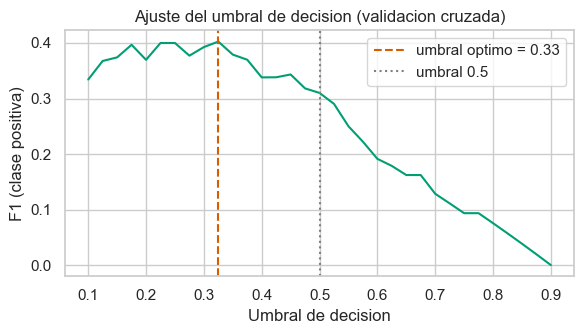

In [21]:
# Se escoge el conjunto de caracteristicas con mejor F1 de la clase positiva en validacion
# cruzada, entre los explorados en las Secciones 9.2 y 9.3 (misma metrica de seleccion del proyecto)
conjuntos_tr = {'MFCC (40)': X_train, 'MFCC + deltas (120)': X_train_ext,
                'MFCC + espectral (64)': X_train_esp}
conjuntos_te = {'MFCC (40)': X_test, 'MFCC + deltas (120)': X_test_ext,
                'MFCC + espectral (64)': X_test_esp}
f1_conjunto = {n: evaluar(construir_modelo(nombre_mejor, fila_ganadora[nombre_mejor]), Xc)['f1']
               for n, Xc in conjuntos_tr.items()}
conjunto_final = max(f1_conjunto, key=f1_conjunto.get)
X_tr_final = conjuntos_tr[conjunto_final]
X_te_final = conjuntos_te[conjunto_final]
print('F1 (clase positiva) en CV por conjunto de caracteristicas:', f1_conjunto)
print('Caracteristicas elegidas:', conjunto_final)

modelo_final = construir_modelo(nombre_mejor, fila_ganadora[nombre_mejor])

# Probabilidades fuera de muestra (sin fuga) para elegir el umbral
proba_oof = cross_val_predict(modelo_final, X_tr_final, y_train, groups=grupos_train,
                              cv=kfold, method='predict_proba')[:, 1]
umbrales = np.linspace(0.10, 0.90, 33)
f1_por_umbral = [f1_score(y_train, (proba_oof >= u).astype(int), zero_division=0) for u in umbrales]
umbral_opt = float(umbrales[int(np.argmax(f1_por_umbral))])
print(f'Umbral optimo (maximiza F1 en CV): {umbral_opt:.3f}  '
      f'(por defecto 0.5 -> F1={f1_por_umbral[np.argmin(np.abs(umbrales-0.5))]:.3f}, '
      f'optimo -> F1={max(f1_por_umbral):.3f})')

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(umbrales, f1_por_umbral, color=PALETA[2])
ax.axvline(umbral_opt, color=PALETA[3], linestyle='--', label=f'umbral optimo = {umbral_opt:.2f}')
ax.axvline(0.5, color='gray', linestyle=':', label='umbral 0.5')
ax.set_xlabel('Umbral de decision'); ax.set_ylabel('F1 (clase positiva)')
ax.set_title('Ajuste del umbral de decision (validacion cruzada)')
ax.legend()
plt.tight_layout()
plt.savefig('figures/umbral.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Evaluacion final en el conjunto de test

Recien ahora se emplea el conjunto de test (20%) separado al inicio. Se entrena el modelo mejorado con todo el train y se evalua una sola vez, aplicando el umbral seleccionado. Se reporta la matriz de confusion con los porcentajes por clase y el accuracy total, y se compara con la linea base para cuantificar la mejora en la deteccion de positivos.

In [22]:
# Modelo de la linea base (mejor modelo, umbral 0.5, sin balanceo) para comparar
base = construir_modelo(nombre_mejor, fila_ganadora[nombre_mejor])
base.fit(X_train, y_train)
y_pred_base = base.predict(X_test)

# Modelo mejorado: mejor modelo de la linea base con el umbral optimo (Seccion 9.3)
modelo_final.fit(X_tr_final, y_train)
proba_test = modelo_final.predict_proba(X_te_final)[:, 1]
y_pred = (proba_test >= umbral_opt).astype(int)

def resumen(y_true, y_hat):
    return {
        'accuracy': round(accuracy_score(y_true, y_hat), 3),
        'balanced_acc': round(balanced_accuracy_score(y_true, y_hat), 3),
        'precision_pos': round(precision_score(y_true, y_hat, zero_division=0), 3),
        'recall_pos': round(recall_score(y_true, y_hat, zero_division=0), 3),
        'f1_pos': round(f1_score(y_true, y_hat, zero_division=0), 3),
    }

comparacion_final = pd.DataFrame([
    {'modelo': f'Linea base ({nombre_mejor}, umbral 0.5)', **resumen(y_test, y_pred_base)},
    {'modelo': f'Mejorado ({nombre_mejor}, umbral {umbral_opt:.2f})', **resumen(y_test, y_pred)},
])
comparacion_final.to_csv('results/test_final.csv', index=False)
print('Configuracion final:', nombre_mejor, '|', conjunto_final, '|',
      f'umbral={umbral_opt:.3f}')
print()
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive'], zero_division=0))
comparacion_final

Configuracion final: SVM | MFCC + espectral (64) | umbral=0.325

              precision    recall  f1-score   support

    Negative       0.93      0.97      0.95       242
    Positive       0.81      0.60      0.69        48

    accuracy                           0.91       290
   macro avg       0.87      0.79      0.82       290
weighted avg       0.91      0.91      0.91       290



,modelo,accuracy,balanced_acc,precision_pos,recall_pos,f1_pos
0,"Linea base (SVM, umbral 0.5)",0.879,0.694,0.741,0.417,0.533
1,"Mejorado (SVM, umbral 0.33)",0.910,0.788,0.806,0.604,0.690


Matriz de confusion (conteos):
[[235   7]
 [ 19  29]]


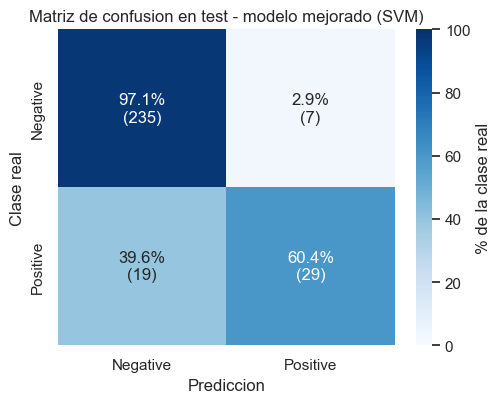

In [23]:
mc = confusion_matrix(y_test, y_pred)
mc_pct = confusion_matrix(y_test, y_pred, normalize='true') * 100

print('Matriz de confusion (conteos):')
print(mc)

fig, ax = plt.subplots(figsize=(5.2, 4.2))
etiquetas = [[f'{pct:.1f}%\n({n})' for pct, n in zip(fila_pct, fila_n)]
             for fila_pct, fila_n in zip(mc_pct, mc)]
sns.heatmap(mc_pct, annot=etiquetas, fmt='', cmap='Blues', vmin=0, vmax=100,
            xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'],
            cbar_kws={'label': '% de la clase real'}, ax=ax)
ax.set_xlabel('Prediccion')
ax.set_ylabel('Clase real')
ax.set_title(f'Matriz de confusion en test - modelo mejorado ({nombre_mejor})')
plt.tight_layout()
plt.savefig('figures/matriz_confusion_test.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Conclusiones

- Se compararon los cuatro modelos solicitados (Regresion Logistica, SVM, Arbol de Decision y KNN) y, adicionalmente, Random Forest, entrenados con validacion cruzada de 5 folds a nivel de paciente. El mejor por F1 de la clase positiva fue el SVM con kernel RBF y C=10.

- El accuracy por si solo resulta enganoso con el desbalance 89/11. Random Forest alcanzo el mayor accuracy (0.908) pero un recall de la clase positiva de apenas 0.04, es decir, practicamente no detecta casos de COVID. Por ello la seleccion del modelo se baso en el F1 y el recall de la clase positiva.

- Se exploraron varias estrategias dentro de lo permitido. La reduccion de dimensionalidad (PCA y LDA), la ponderacion de clases (`class_weight='balanced'`) y los deltas de MFCC no mejoraron el F1 de la clase positiva en validacion cruzada y se documentan como exploracion. En cambio, dos estrategias si aportaron y se incorporaron al modelo final: (i) enriquecer el vector de caracteristicas con descriptores espectrales de librosa (contraste espectral, cruces por cero, centroide, ancho de banda, rolloff y energia RMS), que eleva el F1 de la clase positiva en validacion cruzada de 0.339 a 0.375 (64 caracteristicas); y (ii) el ajuste del umbral de decision de 0.5 a 0.33, elegido por validacion cruzada.

- El modelo final (SVM RBF con C=10 sobre las 64 caracteristicas y umbral 0.33) mejora de forma clara la deteccion de la clase positiva frente a la linea base (SVM sobre 40 MFCC con umbral 0.5): en el conjunto de test el recall de positivos pasa de 0.417 a 0.604, el F1 de 0.533 a 0.690, la balanced accuracy de 0.694 a 0.788 y la exactitud global de 0.879 a 0.910. La matriz de confusion del modelo final detecta 29 de 48 casos positivos (60.4%) y clasifica correctamente 235 de 242 negativos (97.1%).

- El principal factor limitante sigue siendo el desbalance del conjunto y el uso exclusivo del sonido de la tos. Como trabajo futuro, disponer de mas grabaciones positivas o incorporar mas informacion acustica podria mejorar aun mas la deteccion.

- Todo el proyecto emplea la semilla 42 y separa los conjuntos a nivel de paciente para evitar la fuga de datos, por lo que los resultados son reproducibles. Se observa que la proporcion de positivos difiere entre el train (9.6%) y el test (16.6%): esto se debe a que unos pocos pacientes positivos aportan muchas grabaciones y la particion se realiza por paciente; se prioriza evitar la fuga de datos por encima de igualar exactamente las proporciones.

- Como demostracion practica, el modelo se desplego en una aplicacion web (https://ml-project-classification.onrender.com) que graba una tos y estima el riesgo con el mismo flujo de librosa y scikit-learn; ademas, con consentimiento del usuario, recolecta grabaciones de forma anonima para ampliar el conjunto de datos.